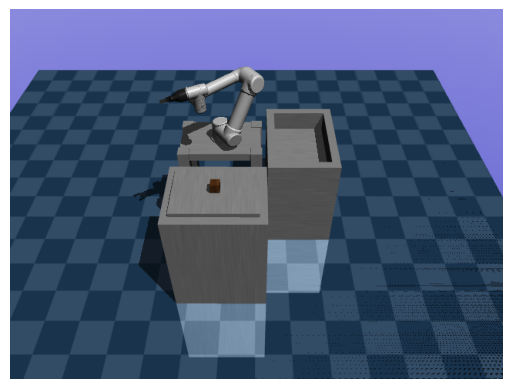

In [ ]:
from pathlib import Path
import numpy as np
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPDController import RobotPDController
import matplotlib.pyplot as plt

MODEL_PATH = Path.cwd().parent / "models" / "UR5gripper_2_finger_KKI.xml"
MujModel = RobotMujocoModel(MODEL_PATH)
warm_start_controller = RobotPDController(MujModel)

q0 = MujModel.actuated_joint_positions
v0 = np.zeros_like(MujModel.v_indices())
x0 = np.concatenate([list(q0.values()), list(v0)])

q_target = MujModel.random_actuated_q()
v_target = np.zeros_like(MujModel.v_indices())
target = np.concatenate([list(q_target.values()), list(v_target)])
MujModel.joint_positions = q_target
MujModel.snapshot(plot=True)
MujModel.joint_positions = q0
warm_xs, warm_us = warm_start_controller.compute_control(x0, target, 3000)


In [6]:
print(f"Length Warm xs: {len(warm_xs)}")

Length Warm xs: 3001
